# A/B Testing & Hypothesis Testing

### Conversion Rate Analysis Using Python

## 1. Project Objective

The objective of this project is to compare Variant A and Variant B
and determine whether there is a statistically significant difference
in checkout conversion rates.

## 2. Import Libraries

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [7]:
from google.colab import files

uploaded = files.upload()

Saving checkout_ab_test_v2.csv to checkout_ab_test_v2.csv


In [8]:
import pandas as pd

df = pd.read_csv("checkout_ab_test_v2.csv")

df.head()

,VisitorID,Variant,Timestamp,Device,TrafficSource,CheckoutStarted,Converted,OrderValueINR
0,VIS-00001,A,2026-07-10T14:33:00,Tablet,Paid,Yes,No,0
1,VIS-00002,B,2026-07-01T13:41:00,Tablet,Paid,No,No,0
2,VIS-00003,A,2026-07-18T04:55:00,Tablet,Paid,No,No,0
3,VIS-00004,B,2026-07-17T22:45:00,Desktop,Paid,No,No,0
4,VIS-00005,A,2026-07-17T23:44:00,Mobile,Direct,Yes,No,0


## 4. Data Exploration

In [10]:
df.shape

(1200, 8)

In [11]:
df.columns

Index(['VisitorID', 'Variant', 'Timestamp', 'Device', 'TrafficSource',
       'CheckoutStarted', 'Converted', 'OrderValueINR'],
      dtype='object')

In [12]:
df.isnull().sum()

,0
VisitorID,0
Variant,0
Timestamp,0
Device,0
TrafficSource,0
CheckoutStarted,0
Converted,0
OrderValueINR,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   VisitorID        1200 non-null   object
 1   Variant          1200 non-null   object
 2   Timestamp        1200 non-null   object
 3   Device           1200 non-null   object
 4   TrafficSource    1200 non-null   object
 5   CheckoutStarted  1200 non-null   object
 6   Converted        1200 non-null   object
 7   OrderValueINR    1200 non-null   int64 
dtypes: int64(1), object(7)
memory usage: 75.1+ KB


In [25]:
df["Converted"].value_counts()

,count
Converted,


In [26]:
df = pd.read_csv("checkout_ab_test_v2.csv")

df["Converted"].value_counts()

,count
Converted,
No,1072
Yes,128


In [27]:
df.groupby("Variant")["Converted"].apply(lambda x: (x == "Yes").sum())

,Converted
Variant,
A,57
B,71


In [28]:
conversion_rate = df.groupby("Variant")["Converted"].apply(
    lambda x: (x == "Yes").mean() * 100
)

conversion_rate

,Converted
Variant,
A,9.500000
B,11.833333


In [29]:
id="p7x4qn"
a_rate = conversion_rate["A"]
b_rate = conversion_rate["B"]

absolute_difference = b_rate - a_rate
relative_lift = ((b_rate - a_rate) / a_rate) * 100

print("Absolute Difference:", round(absolute_difference, 2), "%")
print("Relative Lift:", round(relative_lift, 2), "%")

Absolute Difference: 2.33 %
Relative Lift: 24.56 %


## 5. Hypothesis Testing

### Null Hypothesis (H₀)
There is no statistically significant difference between the conversion
rates of Variant A and Variant B.

### Alternative Hypothesis (H₁)
There is a statistically significant difference between the conversion
rates of Variant A and Variant B.

Significance Level (α) = 0.05

## 6. Two-Proportion Z-Test

In [31]:
from statsmodels.stats.proportion import proportions_ztest

conversions = [
    (df[df["Variant"] == "A"]["Converted"] == "Yes").sum(),
    (df[df["Variant"] == "B"]["Converted"] == "Yes").sum()
]

total_users = [
    (df["Variant"] == "A").sum(),
    (df["Variant"] == "B").sum()
]

z_stat, p_value = proportions_ztest(conversions, total_users)

print("Z-statistic:", round(z_stat, 3))
print("P-value:", round(p_value, 3))

Z-statistic: -1.309
P-value: 0.19


## 7. Chi-Square Test

In [32]:
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Variant"], df["Converted"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square statistic:", round(chi2, 3))
print("P-value:", round(p_value, 3))
print("Degrees of freedom:", dof)

Chi-square statistic: 1.478
P-value: 0.224
Degrees of freedom: 1


## 8. Data Visualizations

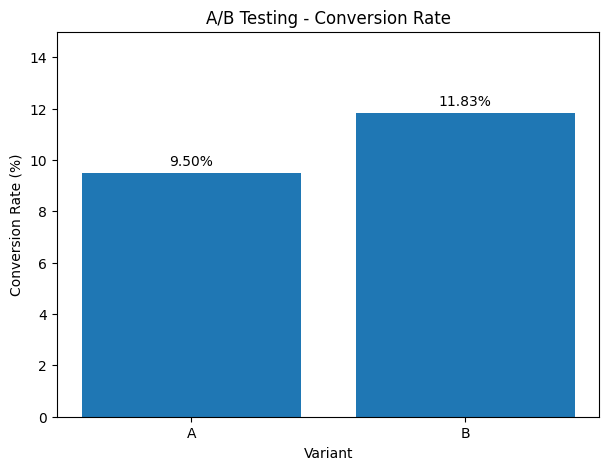

In [33]:
# A vs B Conversion Rate Bar Chart

import matplotlib.pyplot as plt

rates = df.groupby("Variant")["Converted"].apply(
    lambda x: (x == "Yes").mean() * 100
)

plt.figure(figsize=(7, 5))

bars = plt.bar(rates.index, rates.values)

plt.title("A/B Testing - Conversion Rate")
plt.xlabel("Variant")
plt.ylabel("Conversion Rate (%)")
plt.ylim(0, 15)

for bar, value in zip(bars, rates.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.3,
        f"{value:.2f}%",
        ha="center"
    )

plt.show()

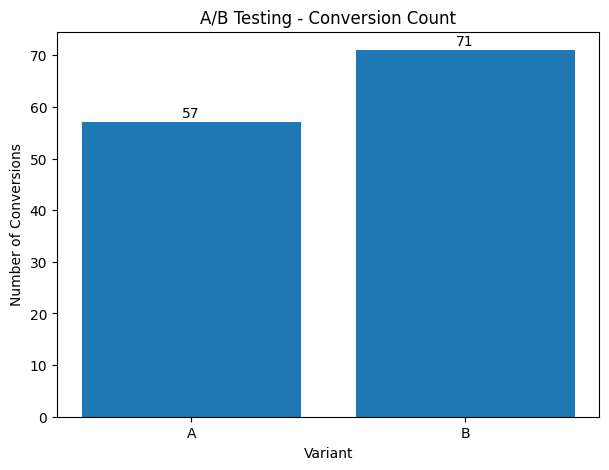

In [34]:
# Conversion Count Chart

conversion_counts = df.groupby("Variant")["Converted"].apply(
    lambda x: (x == "Yes").sum()
)

plt.figure(figsize=(7, 5))

bars = plt.bar(conversion_counts.index, conversion_counts.values)

plt.title("A/B Testing - Conversion Count")
plt.xlabel("Variant")
plt.ylabel("Number of Conversions")

for bar, value in zip(bars, conversion_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 1,
        str(value),
        ha="center"
    )

plt.show()

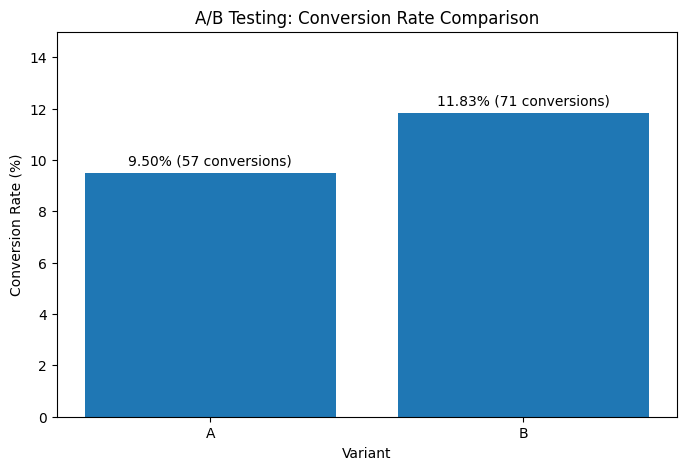

In [35]:
# A vs B Conversion Rate + Count


fig, ax1 = plt.subplots(figsize=(8, 5))

variants = ["A", "B"]
rates = [
    df[df["Variant"] == "A"]["Converted"].eq("Yes").mean() * 100,
    df[df["Variant"] == "B"]["Converted"].eq("Yes").mean() * 100
]

counts = [
    df[df["Variant"] == "A"]["Converted"].eq("Yes").sum(),
    df[df["Variant"] == "B"]["Converted"].eq("Yes").sum()
]

bars = ax1.bar(variants, rates)

ax1.set_title("A/B Testing: Conversion Rate Comparison")
ax1.set_xlabel("Variant")
ax1.set_ylabel("Conversion Rate (%)")
ax1.set_ylim(0, 15)

for bar, rate, count in zip(bars, rates, counts):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        rate + 0.3,
        f"{rate:.2f}% ({count} conversions)",
        ha="center"
    )

plt.show()

## 9. Final Conclusion

Variant B showed a higher observed conversion rate (11.83%)
compared with Variant A (9.50%).

However, the two-proportion Z-test produced a p-value of 0.190
and the Chi-Square test produced a p-value of 0.224.

Both p-values are greater than the significance level of 0.05.
Therefore, there is insufficient statistical evidence to conclude
that Variant B produces a statistically significant change in
conversion rate compared with Variant A.

The observed difference should therefore be interpreted as a
sample-level difference rather than conclusive evidence of a
change in conversion performance.